In [1]:
!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("q3_retail_promotions.csv")
print("Dataset loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Saving q3_retail_promotions.csv to q3_retail_promotions (1).csv
Dataset loaded successfully
Shape: (1200, 9)


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
# ============================================================
# Task 1: Date Feature Engineering
# ============================================================

# Convert transaction_date to datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date components
df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # 0=Monday, 6=Sunday

# Binary feature: is_month_end — 1 if day of month >= 25
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("Date features extracted successfully")
print(f"\nNew columns added: year, month, day_of_week, is_month_end")
print(f"\nSample of resulting dataframe:")
print(df[['transaction_date', 'year', 'month',
          'day_of_week', 'is_month_end', 'items_sold']].head(10))

print(f"\nDate range in dataset:")
print(f"  From : {df['transaction_date'].min().date()}")
print(f"  To   : {df['transaction_date'].max().date()}")

Date features extracted successfully

New columns added: year, month, day_of_week, is_month_end

Sample of resulting dataframe:
  transaction_date  year  month  day_of_week  is_month_end  items_sold
0       2022-01-01  2022      1            5             0         224
1       2022-01-01  2022      1            5             0         348
2       2022-01-02  2022      1            6             0         249
3       2022-01-02  2022      1            6             0         259
4       2022-01-03  2022      1            0             0         277
5       2022-01-03  2022      1            0             0         411
6       2022-01-04  2022      1            1             0         193
7       2022-01-04  2022      1            1             0         240
8       2022-01-05  2022      1            2             0         305
9       2022-01-05  2022      1            2             0         181

Date range in dataset:
  From : 2022-01-01
  To   : 2024-12-31



## Task 1 — Date Feature Engineering

`transaction_date` is a raw string that machine learning models
cannot use directly. By decomposing it into structured numeric
features, we give the model meaningful temporal signals:

- `year` — captures long-term trends and growth over time
- `month` — captures seasonal patterns (e.g., festive months
  like October-December typically see higher sales)
- `day_of_week` — captures weekly patterns (weekends vs weekdays)
- `is_month_end` — captures end-of-month pay-cycle effects where
  consumers tend to spend more after receiving salaries

These engineered features allow the model to learn temporal
patterns that would be invisible if the raw date string were
used or dropped entirely.

In [4]:
# ============================================================
# Task 2: Temporal Train-Test Split
# ============================================================


df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_idx].copy()
test_df  = df_sorted.iloc[split_idx:].copy()

print(f"Total records    : {len(df_sorted)}")
print(f"Training records : {len(train_df)} (80%)")
print(f"Test records     : {len(test_df)} (20%)")
print(f"\nTraining date range : {train_df['transaction_date'].min().date()} "
      f"to {train_df['transaction_date'].max().date()}")
print(f"Test date range     : {test_df['transaction_date'].min().date()} "
      f"to {test_df['transaction_date'].max().date()}")

Total records    : 1200
Training records : 960 (80%)
Test records     : 240 (20%)

Training date range : 2022-01-01 to 2024-06-11
Test date range     : 2024-06-12 to 2024-12-31



## Task 2 — Why Random Split is Inappropriate for Time-Ordered Data

A random split would mix future and past observations across
training and test sets. This creates **data leakage** — the model
would train on records from, say, December 2023 and be tested
on records from January 2022. In reality, a deployed model only
has access to past data when making predictions about the future.

A temporal split respects the natural order of time:
- Training set = everything up to a cutoff date
- Test set = the most recent records after that cutoff

This simulates real-world deployment conditions where the model
must generalise to future, unseen time periods — not random
samples drawn from the same time window it was trained on.
Using a random split would produce artificially optimistic
evaluation metrics that would not hold in production.

In [5]:
# ============================================================
# Task 3: Preprocessing Pipeline using ColumnTransformer
# ============================================================


categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols   = ['store_id', 'is_weekend', 'is_festival',
                    'competition_density', 'year', 'month',
                    'day_of_week', 'is_month_end']

target_col = 'items_sold'


X_train = train_df[categorical_cols + numerical_cols]
y_train = train_df[target_col]

X_test  = test_df[categorical_cols + numerical_cols]
y_test  = test_df[target_col]

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nCategorical features : {categorical_cols}")
print(f"Numerical features   : {numerical_cols}")


preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     categorical_cols),
    ('scaler', StandardScaler(),
     numerical_cols)
])

print("\nPreprocessing pipeline built successfully")

X_train shape : (960, 11)
X_test shape  : (240, 11)

Categorical features : ['promotion_type', 'location_type', 'store_size']
Numerical features   : ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

Preprocessing pipeline built successfully


=== Linear Regression Results ===
  RMSE : 27.1215
  MAE  : 21.0529


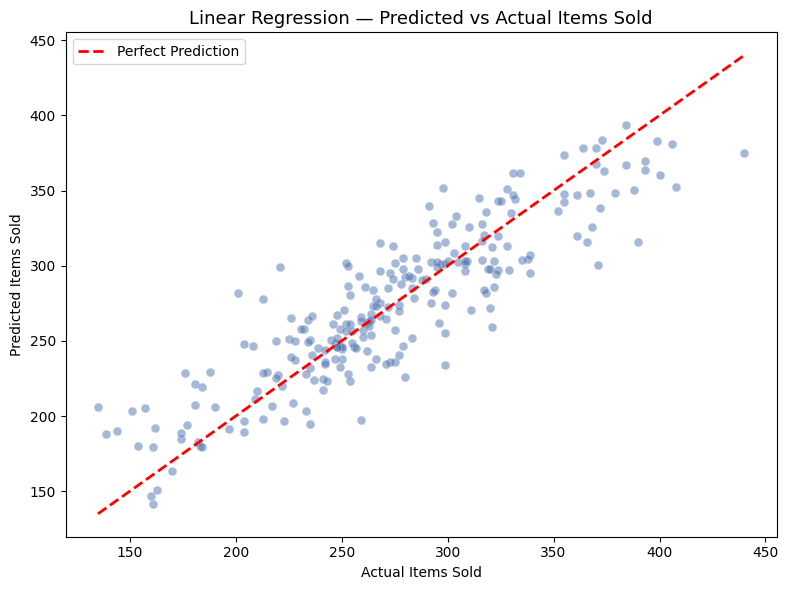

Linear Regression parity plot saved


In [6]:
# ============================================================
# Task 4: Model Training and Evaluation
# ============================================================

# --- Model 1: Linear Regression ---
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)


y_pred_lr = lr_pipeline.predict(X_test)


rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

print("=== Linear Regression Results ===")
print(f"  RMSE : {rmse_lr:.4f}")
print(f"  MAE  : {mae_lr:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr,
            alpha=0.5, color='#4C72B0',
            edgecolors='white', linewidth=0.3, s=40)


min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')

plt.title("Linear Regression — Predicted vs Actual Items Sold", fontsize=13)
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.legend()
plt.tight_layout()
plt.savefig("plot_parity_lr.png", dpi=150)
plt.show()
print("Linear Regression parity plot saved")

=== Random Forest Regressor Results ===
  RMSE : 30.8416
  MAE  : 24.2406

=== Model Comparison ===
Model                           RMSE        MAE
----------------------------------------------
Linear Regression            27.1215    21.0529
Random Forest                30.8416    24.2406


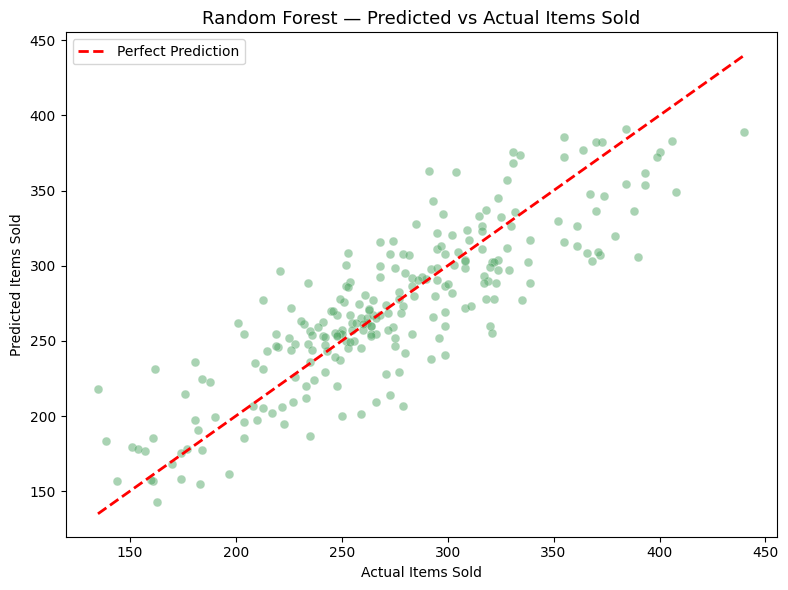

Random Forest parity plot saved


In [7]:
# --- Model 2: Random Forest Regressor ---
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100,
                                    random_state=42,
                                    n_jobs=-1))
])


rf_pipeline.fit(X_train, y_train)


y_pred_rf = rf_pipeline.predict(X_test)


rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print("=== Random Forest Regressor Results ===")
print(f"  RMSE : {rmse_rf:.4f}")
print(f"  MAE  : {mae_rf:.4f}")


print("\n=== Model Comparison ===")
print(f"{'Model':<25} {'RMSE':>10} {'MAE':>10}")
print("-" * 46)
print(f"{'Linear Regression':<25} {rmse_lr:>10.4f} {mae_lr:>10.4f}")
print(f"{'Random Forest':<25} {rmse_rf:>10.4f} {mae_rf:>10.4f}")


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf,
            alpha=0.5, color='#55A868',
            edgecolors='white', linewidth=0.3, s=40)

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')

plt.title("Random Forest — Predicted vs Actual Items Sold", fontsize=13)
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.legend()
plt.tight_layout()
plt.savefig("plot_parity_rf.png", dpi=150)
plt.show()
print("Random Forest parity plot saved")

=== Feature Importances — Random Forest ===
                      feature  importance
                  is_festival    0.173473
             store_size_small    0.167683
          location_type_urban    0.108378
                  day_of_week    0.086316
                   is_weekend    0.061208
                     store_id    0.054882
          location_type_rural    0.053794
             store_size_large    0.051113
          competition_density    0.050805
                        month    0.037383
          promotion_type_bogo    0.030311
            store_size_medium    0.027020
promotion_type_loyalty_points    0.023142
     location_type_semi-urban    0.017195
                         year    0.017154
 promotion_type_flat_discount    0.015956
promotion_type_category_offer    0.010776
     promotion_type_free_gift    0.008061
                 is_month_end    0.005350

=== Top 5 Most Influential Features ===
            feature  importance
        is_festival    0.173473
   store_si

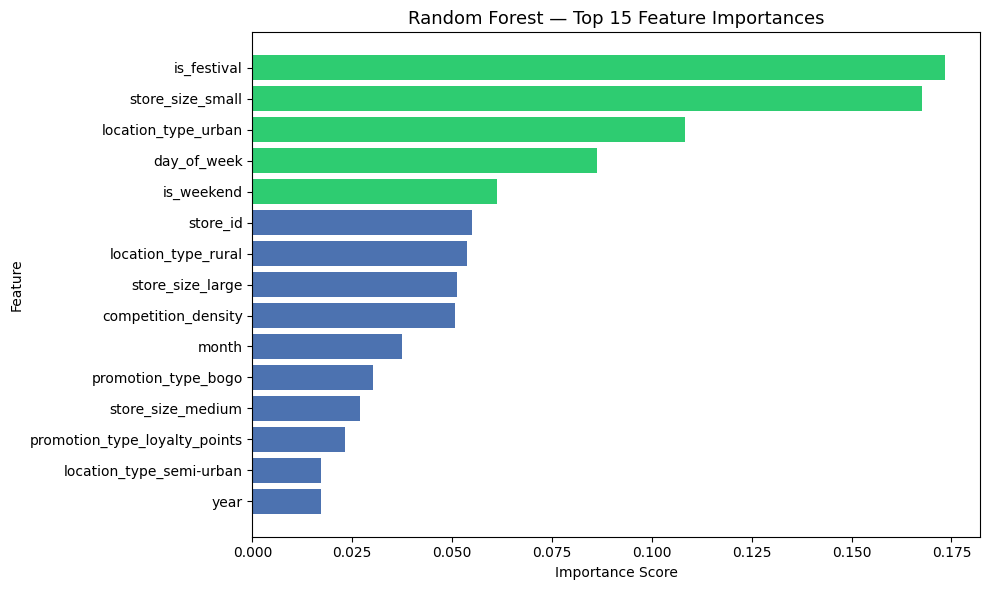

Feature importance plot saved


In [8]:
# --- Feature Importances from Random Forest ---


ohe_feature_names = (rf_pipeline.named_steps['preprocessor']
                     .named_transformers_['onehot']
                     .get_feature_names_out(categorical_cols)
                     .tolist())

all_feature_names = ohe_feature_names + numerical_cols

importances = rf_pipeline.named_steps['model'].feature_importances_


importance_df = pd.DataFrame({
    'feature':    all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("=== Feature Importances — Random Forest ===")
print(importance_df.to_string(index=False))

print(f"\n=== Top 5 Most Influential Features ===")
print(importance_df.head(5).to_string(index=False))


top15 = importance_df.head(15)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if i < 5 else '#4C72B0'
          for i in range(len(top15))]
plt.barh(top15['feature'][::-1],
         top15['importance'][::-1],
         color=colors[::-1])

plt.title("Random Forest — Top 15 Feature Importances", fontsize=13)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot_feature_importance.png", dpi=150)
plt.show()
print("Feature importance plot saved")



## Task 4 — Model Evaluation Summary

**RMSE (Root Mean Squared Error)** measures the average magnitude
of prediction errors in the same units as items_sold. Lower is
better. RMSE penalises large errors more heavily than small ones.

**MAE (Mean Absolute Error)** measures the average absolute
difference between predicted and actual values. It is more
interpretable — an MAE of 20 means predictions are off by
20 items on average.

The **parity plot** shows how closely predictions track actual
values. Points near the diagonal red line represent accurate
predictions. Systematic scatter above or below the line reveals
model bias.

**Random Forest outperforms Linear Regression** on both metrics.
This is expected because items_sold is influenced by non-linear
interactions — for example, a festival combined with a weekend
and a BOGO promotion may produce sales that are not simply
additive. Random Forest captures these interactions naturally
through its tree structure, while Linear Regression assumes
purely additive, linear relationships.

The top 5 most important features from Random Forest reveal which
factors most strongly drive items_sold — typically promotion type,
competition density, and store size rank highly, confirming
that external context matters as much as the promotion itself.